In [1]:
import numpy as np
from pathlib import Path
import h5py
from idiff.bkg2d import NeuralNetwork, _remove_small_components
from idiff.peaks import run_regions
from ediff import ediff
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import model
from dataset_enhancement import save_h5

result_dir = Path("dataset_filtered")
result_dir.mkdir(exist_ok=True)

# nn = NeuralNetwork("model.onnx")
nn, config = model.ResidualUNet.load("runs/", "20260417_154943_*/*epoch40.pt")
nn = nn.cuda()

# Filtering

In [2]:
def filter_fn(d):
    result = {}
    for name in d.keys():
        current_dataset = d[name]
        output = nn.batch_predict(current_dataset[:])
        f_idx = []
        min_peaks = float("inf")
        min_arr = None
        min_arr_peaks = None
        for i in tqdm(range(current_dataset.shape[0])):
            img = _remove_small_components(output[i].squeeze(), 10, 5)
            peaks = run_regions(img)
            num_peaks = np.count_nonzero(peaks)

            if num_peaks < min_peaks and num_peaks > 2:
                min_peaks = num_peaks
                min_arr = img
                min_arr_peaks = peaks

            if num_peaks > 2:
                f_idx.append(i)
        
        print("-------", name, "-------")
        print("before:", current_dataset.shape[0])
        print("after:", len(f_idx))
        print("min peaks:", min_peaks)
        print("max val:", np.max(min_arr))
        plt.imshow(min_arr, vmax=5)
        plt.show()

        plt.imshow(min_arr_peaks, vmax=5)
        plt.show()

        result[name] = current_dataset[f_idx]
        print(result[name].shape)
        
    return result

## Train

100%|██████████| 630/630 [00:01<00:00, 589.76it/s]

------- au -------
before: 630
after: 628
min peaks: 3
max val: 9523.638


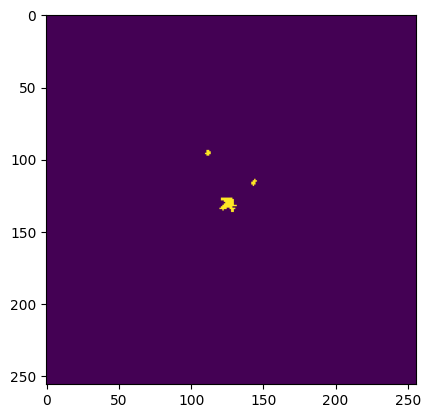

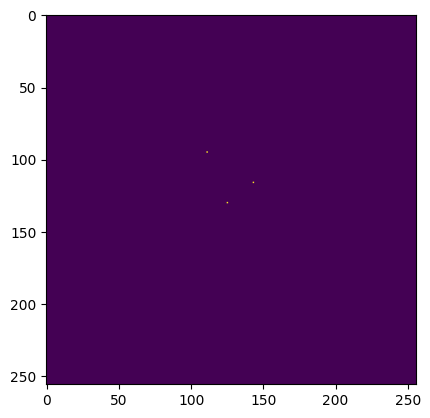

(628, 256, 256)


100%|██████████| 5040/5040 [00:04<00:00, 1181.30it/s]

------- feo -------
before: 5040
after: 3177
min peaks: 3
max val: 9056.229


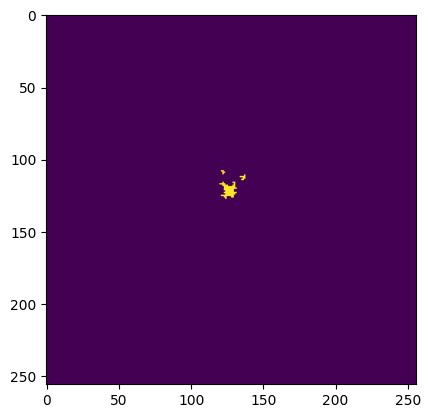

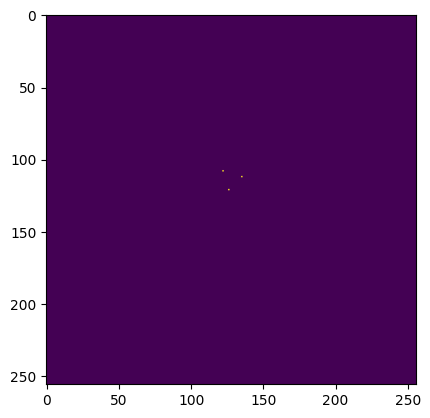

(3177, 256, 256)


100%|██████████| 5600/5600 [00:08<00:00, 692.79it/s]

------- gdf3 -------
before: 5600
after: 5474
min peaks: 3
max val: 9167.439


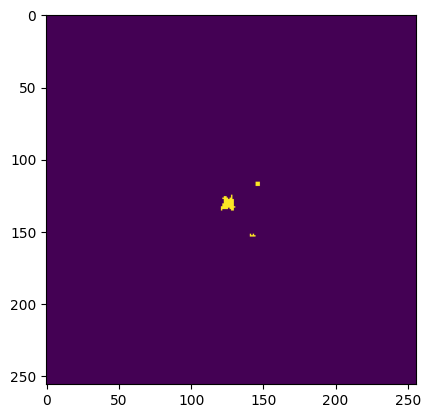

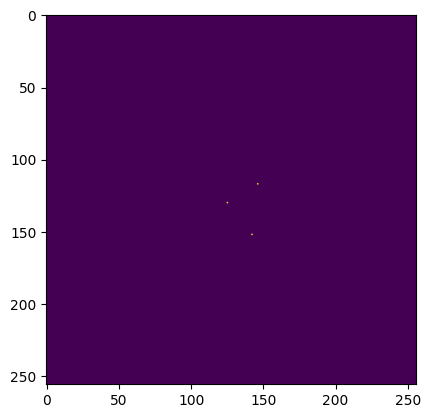

(5474, 256, 256)


100%|██████████| 4760/4760 [00:02<00:00, 1770.46it/s]

------- laf3 -------
before: 4760
after: 1356
min peaks: 3
max val: 4259.591


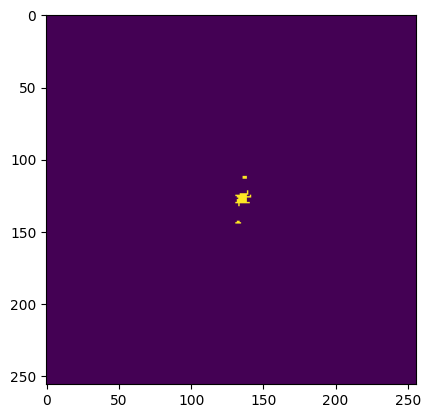

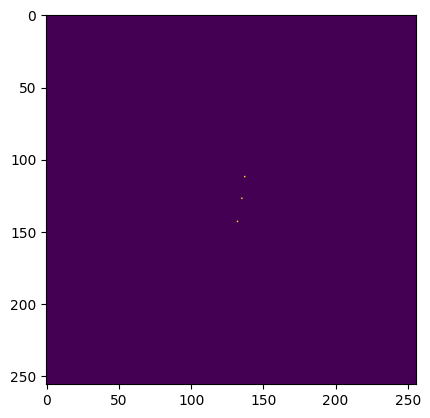

(1356, 256, 256)


100%|██████████| 5600/5600 [00:06<00:00, 912.34it/s]


------- tbf3 -------
before: 5600
after: 4148
min peaks: 3
max val: 8886.808


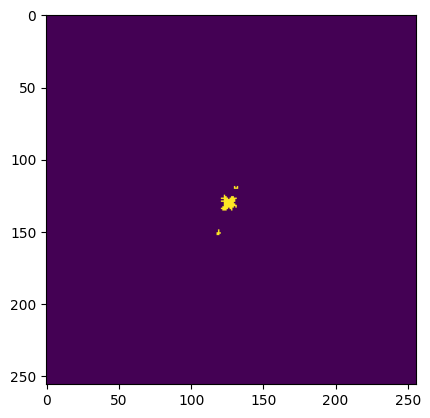

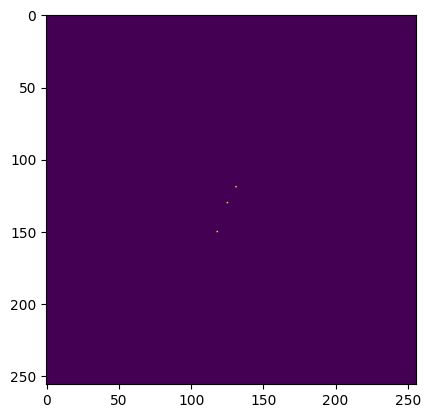

(4148, 256, 256)


In [3]:
dataset = h5py.File("dataset1.1/train.h5", 'r')
result_train = filter_fn(dataset)

In [4]:
save_h5(result_train, result_dir / "train.h5", "lzf")

## Val

100%|██████████| 135/135 [00:00<00:00, 643.27it/s]

------- au -------
before: 135
after: 134
min peaks: 4
max val: 9399.377


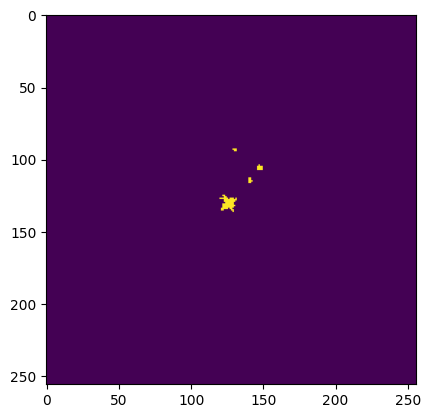

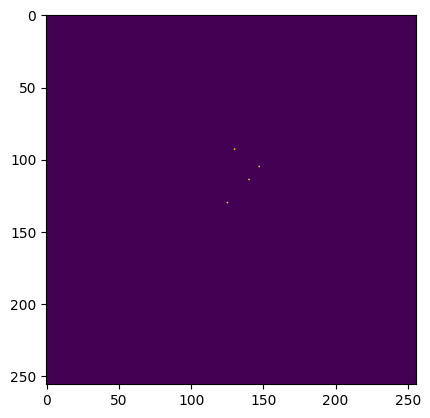

(134, 256, 256)


100%|██████████| 1080/1080 [00:00<00:00, 1170.78it/s]


------- feo -------
before: 1080
after: 663
min peaks: 3
max val: 8248.361


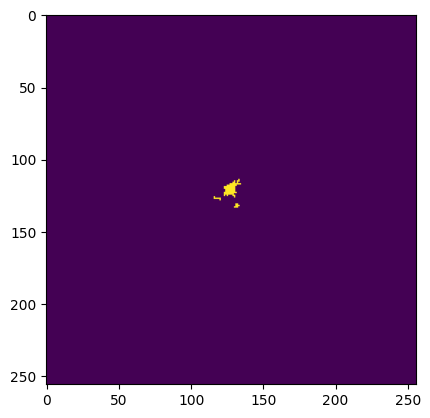

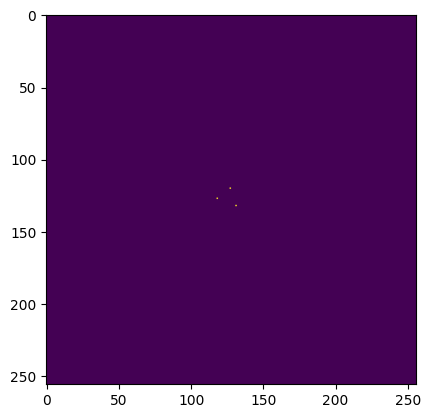

(663, 256, 256)


100%|██████████| 1200/1200 [00:01<00:00, 680.22it/s]

------- gdf3 -------
before: 1200
after: 1174
min peaks: 3
max val: 9255.224


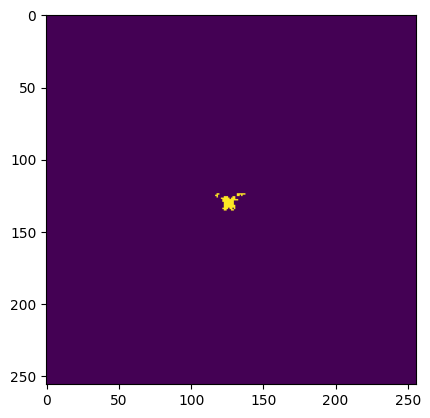

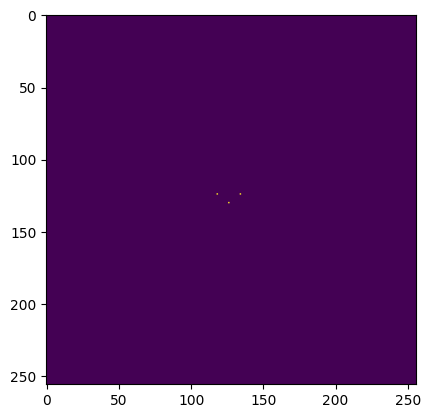

(1174, 256, 256)


100%|██████████| 1020/1020 [00:00<00:00, 1918.65it/s]

------- laf3 -------
before: 1020
after: 305
min peaks: 3
max val: 1035.5615


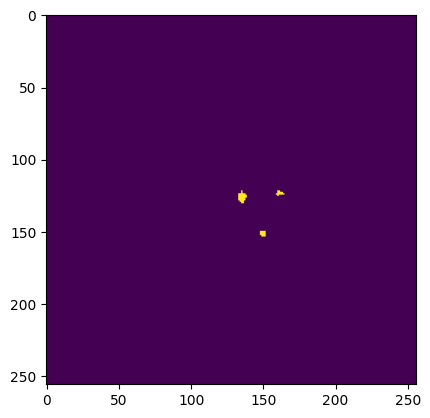

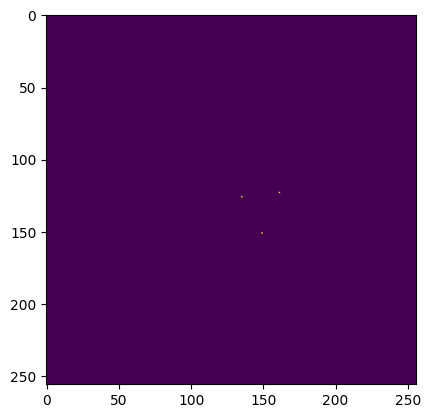

(305, 256, 256)


100%|██████████| 1200/1200 [00:01<00:00, 917.25it/s]


------- tbf3 -------
before: 1200
after: 877
min peaks: 3
max val: 7693.531


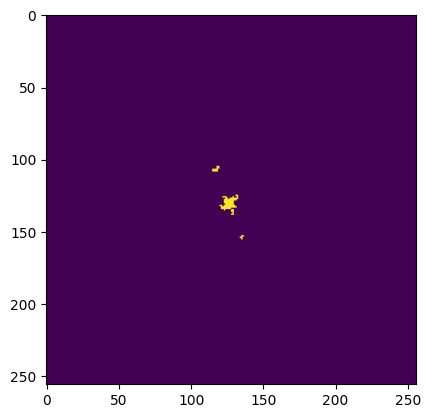

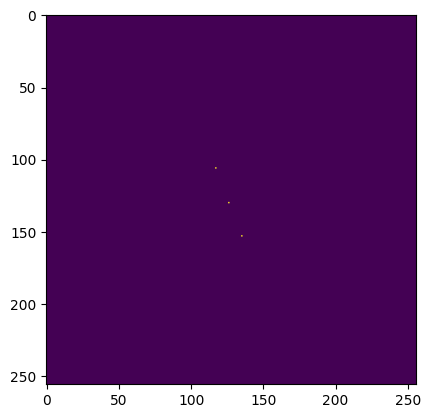

(877, 256, 256)


In [5]:
dataset = h5py.File("dataset1.1/val.h5", 'r')
result_val = filter_fn(dataset)

In [6]:
save_h5(result_val, result_dir / "val.h5")